# Women's Rankings

Get ratings of each team in a given year. This file needs to be ran for every relevant year (starting in 2008). 

### Data Setup

In [1]:
import pandas as pd

season = 2025

df = pd.read_parquet(fr'..\data\unprocessed\womens_sports_reference\full_season_sports_reference_{season}.parquet')

# only include games before NCAA tournament
df = df.loc[df['NCAA Tournament'] == 0, :].reset_index(drop=True)

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Opponent TOV,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo
0,Abilene Christian,2024-11-08,0,-1,Florida International,REG (Non-Conf),1,76.0,73.0,21.0,...,18.0,32.0,0,0,3.0,1.166625,82.52,0.920989,0.884634,82.52
1,Abilene Christian,2024-11-12,0,1,Stephen F. Austin,REG (Non-Conf),-1,65.0,68.0,25.0,...,22.0,22.0,0,0,-3.0,1.166625,74.42,0.873421,0.913733,74.42
2,Abilene Christian,2024-11-16,0,1,North Texas,REG (Non-Conf),-1,60.0,71.0,24.0,...,23.0,17.0,0,0,-11.0,1.399871,76.88,0.780437,0.923517,76.88
3,Abilene Christian,2024-11-19,0,-1,Texas Tech,REG (Non-Conf),-1,40.0,66.0,12.0,...,26.0,20.0,0,0,-26.0,1.500000,67.42,0.593296,0.978938,67.42
4,Abilene Christian,2024-11-21,0,1,Western Kentucky,REG (Non-Conf),-1,64.0,68.0,23.0,...,17.0,16.0,0,0,-4.0,1.214668,72.10,0.887656,0.943135,72.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,Youngstown State,2025-02-20,0,-1,Detroit Mercy,REG (Conf),1,67.0,59.0,26.0,...,14.0,21.0,0,0,8.0,1.338710,73.50,0.911565,0.802721,73.50
10884,Youngstown State,2025-02-22,0,-1,Oakland,REG (Conf),1,52.0,51.0,19.0,...,13.0,19.0,0,0,1.0,1.000000,67.78,0.767188,0.752434,67.78
10885,Youngstown State,2025-02-26,0,-1,Robert Morris,REG (Conf),-1,53.0,76.0,18.0,...,13.0,15.0,0,0,-23.0,1.500000,68.44,0.774401,1.110462,68.44
10886,Youngstown State,2025-03-01,0,1,Cleveland State,REG (Conf),1,73.0,70.0,24.0,...,11.0,21.0,0,0,3.0,1.166625,66.24,1.102053,1.056763,66.24


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10888 entries, 0 to 10887
Data columns (total 59 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Team                         10888 non-null  object        
 1   Date                         10888 non-null  datetime64[ns]
 2   NCAA Tournament              10888 non-null  int32         
 3   Location                     10888 non-null  int8          
 4   Opponent                     10888 non-null  object        
 5   Type                         10888 non-null  object        
 6   Result                       10888 non-null  int8          
 7   Team Score                   10888 non-null  float64       
 8   Opponent Score               10888 non-null  float64       
 9   Team FG                      10888 non-null  float64       
 10  Team FGA                     10888 non-null  float64       
 11  Team FG%                     10888 non-nu

Create recency bias

In [3]:
# games at the beginning of the season should be about 0.8, games at the end will be 1.2

df['Recency Bias'] = 0.996018**(df['Date'].max() - df['Date']).dt.days + 0.2

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias
0,Abilene Christian,2024-11-08,0,-1,Florida International,REG (Non-Conf),1,76.0,73.0,21.0,...,32.0,0,0,3.0,1.166625,82.52,0.920989,0.884634,82.52,0.800067
1,Abilene Christian,2024-11-12,0,1,Stephen F. Austin,REG (Non-Conf),-1,65.0,68.0,25.0,...,22.0,0,0,-3.0,1.166625,74.42,0.873421,0.913733,74.42,0.809721
2,Abilene Christian,2024-11-16,0,1,North Texas,REG (Non-Conf),-1,60.0,71.0,24.0,...,17.0,0,0,-11.0,1.399871,76.88,0.780437,0.923517,76.88,0.819530
3,Abilene Christian,2024-11-19,0,-1,Texas Tech,REG (Non-Conf),-1,40.0,66.0,12.0,...,20.0,0,0,-26.0,1.500000,67.42,0.593296,0.978938,67.42,0.826990
4,Abilene Christian,2024-11-21,0,1,Western Kentucky,REG (Non-Conf),-1,64.0,68.0,23.0,...,16.0,0,0,-4.0,1.214668,72.10,0.887656,0.943135,72.10,0.832014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,Youngstown State,2025-02-20,0,-1,Detroit Mercy,REG (Conf),1,67.0,59.0,26.0,...,21.0,0,0,8.0,1.338710,73.50,0.911565,0.802721,73.50,1.108683
10884,Youngstown State,2025-02-22,0,-1,Oakland,REG (Conf),1,52.0,51.0,19.0,...,19.0,0,0,1.0,1.000000,67.78,0.767188,0.752434,67.78,1.115963
10885,Youngstown State,2025-02-26,0,-1,Robert Morris,REG (Conf),-1,53.0,76.0,18.0,...,15.0,0,0,-23.0,1.500000,68.44,0.774401,1.110462,68.44,1.130699
10886,Youngstown State,2025-03-01,0,1,Cleveland State,REG (Conf),1,73.0,70.0,24.0,...,21.0,0,0,3.0,1.166625,66.24,1.102053,1.056763,66.24,1.141907


### Model Building

##### Team Ratings

In [4]:
X = (
    pd.get_dummies(df['Team']).astype('int8') -
    pd.get_dummies(df['Opponent']).astype('int8')
)

X['Home Field Advantage'] = df['Location'].copy()

X

,Abilene Christian,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,...,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
10884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
10885,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
10886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [5]:
from sklearn.model_selection import GroupKFold
import numpy as np

def get_gkf_data(X, y, w, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # sample weights
        w_train = w[train_index]

        data.append((X_train, X_test, y_train, y_test, w_train))

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Result'].to_numpy(), df['Adjusted Score Differential'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [6]:
def rescale_weights(arr, minimum, maximum):
    """
    Rescale the weights array to match desired weights.
    Assumes the data is already transformed where a 1 point win is 1.00, a blowout is 1.50, and a tie is 0.50.
    Ties will be weighted as half the minimum.
    """

    arr_scaled = ((arr - 1.00) / 0.50) * (maximum - minimum) + minimum
    arr_scaled[arr == 0.50] = minimum / 2
    return arr_scaled

In [7]:
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
import warnings
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    C = trial.suggest_float('C', 0.1, 10, log=True)
    mod = LogisticRegression(penalty='l2', C=C, fit_intercept=False)
    minimum = trial.suggest_float('minimum', 0.1, 1.0, step=0.1)
    maximum = trial.suggest_float('maximum', 1.0, 8.0, step=0.5)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test, w_train in cv_data:
        y_actuals.append(y_test)

        weights = rescale_weights(w_train, minimum, maximum)

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')  # prevent convergence warnings
            mod.fit(X_train, y_train, sample_weight=weights)

        y_preds.append(mod.predict_proba(X_test)[:, 1])

    return log_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'C': 0.2989962524394299, 'minimum': 0.5, 'maximum': 6.5}

In [8]:
minimum = study.best_params['minimum']
maximum = study.best_params['maximum']

weight = rescale_weights(df['Adjusted Score Differential'], minimum, maximum)*df['Recency Bias']

mod = LogisticRegression(penalty='l2', C=study.best_params['C'], fit_intercept=False)

mod.fit(X, df['Result'], sample_weight=weight)

df_ratings = pd.DataFrame(
    {
        'Team': X.columns,
        'BT Rating': mod.coef_[0]
    }
).sort_values(by=['BT Rating'], ascending=False, ignore_index=True)

df_ratings

,Team,BT Rating
0,South Carolina,5.147655
1,Connecticut,4.889345
2,UCLA,4.837455
3,Texas,4.752753
4,Southern California,4.598629
...,...,...
358,Cal State Bakersfield,-3.786623
359,UNC Asheville,-3.810496
360,Arkansas-Pine Bluff,-3.902445
361,Delaware State,-4.006074


Make stronger adjustments based on strength of schedule

In [9]:
team_to_bt_rating = dict(zip(df_ratings['Team'], df_ratings['BT Rating']))

df['Opponent BT Rating'] = df['Opponent'].map(team_to_bt_rating)

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias,Opponent BT Rating
0,Abilene Christian,2024-11-08,0,-1,Florida International,REG (Non-Conf),1,76.0,73.0,21.0,...,0,0,3.0,1.166625,82.52,0.920989,0.884634,82.52,0.800067,-1.376709
1,Abilene Christian,2024-11-12,0,1,Stephen F. Austin,REG (Non-Conf),-1,65.0,68.0,25.0,...,0,0,-3.0,1.166625,74.42,0.873421,0.913733,74.42,0.809721,1.822154
2,Abilene Christian,2024-11-16,0,1,North Texas,REG (Non-Conf),-1,60.0,71.0,24.0,...,0,0,-11.0,1.399871,76.88,0.780437,0.923517,76.88,0.819530,1.348543
3,Abilene Christian,2024-11-19,0,-1,Texas Tech,REG (Non-Conf),-1,40.0,66.0,12.0,...,0,0,-26.0,1.500000,67.42,0.593296,0.978938,67.42,0.826990,1.213321
4,Abilene Christian,2024-11-21,0,1,Western Kentucky,REG (Non-Conf),-1,64.0,68.0,23.0,...,0,0,-4.0,1.214668,72.10,0.887656,0.943135,72.10,0.832014,1.059918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,Youngstown State,2025-02-20,0,-1,Detroit Mercy,REG (Conf),1,67.0,59.0,26.0,...,0,0,8.0,1.338710,73.50,0.911565,0.802721,73.50,1.108683,-1.082220
10884,Youngstown State,2025-02-22,0,-1,Oakland,REG (Conf),1,52.0,51.0,19.0,...,0,0,1.0,1.000000,67.78,0.767188,0.752434,67.78,1.115963,-1.824399
10885,Youngstown State,2025-02-26,0,-1,Robert Morris,REG (Conf),-1,53.0,76.0,18.0,...,0,0,-23.0,1.500000,68.44,0.774401,1.110462,68.44,1.130699,-0.817087
10886,Youngstown State,2025-03-01,0,1,Cleveland State,REG (Conf),1,73.0,70.0,24.0,...,0,0,3.0,1.166625,66.24,1.102053,1.056763,66.24,1.141907,0.690682


In [10]:
# make sure results are 1/-1 for win/loss for this chunk to work properly

def rescale_ratings(arr, minimum, maximum):
    """
    Rescale the ratings array to match desired weights.
    """
    return ((arr - arr.min()) / (arr.max() - arr.min())) * (maximum - minimum) + minimum

def get_sos(result: int, quantiles: list) -> pd.DataFrame:
    """
    Get the strength of teams beat/lost to at different quantiles.
    For example, best win or worst lost.
    """
    data = (
        df.loc[df['Result'] == result, :]
        .groupby(['Team'])['Opponent BT Rating']
        .quantile(quantiles)
        .reset_index()
        .pivot(index='Team', columns='level_1')
        .reset_index()
    )
    data.index.name = None
    if result > 0:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Win' for v in data.columns]
    else:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Loss' for v in data.columns]

    return data

df_advanced_ratings = pd.merge(
    get_sos(-1, [0.00, 0.10, 0.20]),
    get_sos(1, [1.00, 0.90, 0.80]),
    how='outer',
    on=['Team'],
)

df_advanced_ratings.insert(1, 'BT Rating', df_advanced_ratings['Team'].map(team_to_bt_rating))

# in case teams did not win or did not lose a game, just fill it with the team's own rating
for c in df_advanced_ratings.columns[1:]:
    df_advanced_ratings.loc[df_advanced_ratings[c].isna(), c] = df_advanced_ratings['BT Rating']

df_advanced_ratings.insert(
    1,
    'Rating',
    rescale_ratings(
        np.average(df_advanced_ratings.iloc[:, 1:], weights=[0.4] + [0.1]*6, axis=1),
        df_ratings['BT Rating'].min(),
        df_ratings['BT Rating'].max(),
    ),
)

df_advanced_ratings.sort_values(by=['Rating'], ascending=False, inplace=True, ignore_index=True)

df_advanced_ratings

,Team,Rating,BT Rating,0.0 Loss,0.1 Loss,0.2 Loss,0.8 Win,0.9 Win,1.0 Win
0,South Carolina,5.147655,5.147655,4.752753,4.769693,4.786634,3.471315,3.931784,4.752753
1,UCLA,4.908453,4.837455,4.598629,4.598629,4.598629,3.256287,3.333174,5.147655
2,Texas,4.802689,4.752753,4.208653,4.396454,4.584254,3.164713,3.409408,5.147655
3,Connecticut,4.473622,4.889345,3.167398,3.375649,3.583900,2.796632,3.304546,5.147655
4,Southern California,4.409562,4.598629,3.244222,3.437108,3.629995,2.980307,3.775793,4.889345
...,...,...,...,...,...,...,...,...,...
357,Long Island University,-3.460222,-3.668909,-3.064686,-2.870048,-2.606512,-2.832494,-2.638279,-2.444064
358,Arkansas-Pine Bluff,-3.558144,-3.902445,-3.133242,-2.692306,-2.242606,-2.781079,-2.781079,-2.781079
359,UNC Asheville,-3.661215,-3.810496,-3.319318,-2.759141,-1.678986,-3.319318,-3.319318,-3.319318
360,South Carolina State,-3.805312,-4.067205,-4.006074,-1.964022,-1.863348,-3.456670,-3.387994,-3.319318


In [11]:
df_ratings_display = df_advanced_ratings[['Team', 'Rating']].copy()
df_ratings_display.index += 1

df_ratings_display['Strength'] = (np.exp(df_ratings_display['Rating'])/(1 + np.exp(df_ratings_display['Rating'])))*100

df_ratings_display

,Team,Rating,Strength
1,South Carolina,5.147655,99.422058
2,UCLA,4.908453,99.267022
3,Texas,4.802689,99.185917
4,Connecticut,4.473622,98.872270
5,Southern California,4.409562,98.798560
...,...,...,...
358,Long Island University,-3.460222,3.046548
359,Arkansas-Pine Bluff,-3.558144,2.770237
360,UNC Asheville,-3.661215,2.505726
361,South Carolina State,-3.805312,2.176788


##### Adjusted Offense/Defense Ratings

In [12]:
X_offense = pd.get_dummies(
    df['Team']
).astype('int8')

X_offense.columns += ' Offense'

X_defense = -pd.get_dummies(
    df['Opponent']
).astype('int8')

X_defense.columns += ' Defense'

X = pd.concat([X_offense, X_defense], axis=1)

X['Home Field Advantage'] = df['Location'].copy()

X

,Abilene Christian Offense,Air Force Offense,Akron Offense,Alabama Offense,Alabama A&M Offense,Alabama State Offense,Albany (NY) Offense,Alcorn State Offense,American Offense,Appalachian State Offense,...,William & Mary Defense,Winthrop Defense,Wisconsin Defense,Wofford Defense,Wright State Defense,Wyoming Defense,Xavier Defense,Yale Defense,Youngstown State Defense,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
10884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
10885,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
10886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [13]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Team PPP'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 0.8660261758095342}

In [15]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Team PPP'], sample_weight=df['Recency Bias'])

df_ppp = pd.DataFrame(
    {
        'Team': X.columns,
        'Rating': mod.coef_
    }
).sort_values(by=['Rating'], ascending=False, ignore_index=True)

df_ppp

,Team,Rating
0,Connecticut Offense,0.327565
1,South Carolina Offense,0.291824
2,TCU Offense,0.282925
3,South Carolina Defense,0.270330
4,Texas Offense,0.265776
...,...,...
720,Arkansas-Pine Bluff Offense,-0.218292
721,Delaware State Offense,-0.218371
722,Alabama State Offense,-0.220068
723,Massachusetts-Lowell Offense,-0.227100


In [16]:
df_ppp.loc[df_ppp['Team'].str.contains('Home Field'), :]

,Team,Rating
272,Home Field Advantage,0.019967


In [17]:
df_ppp_offense = df_ppp.loc[df_ppp['Team'].str.contains(' Offense$', regex=True), :].reset_index(drop=True)

df_ppp_offense['Team'] = df_ppp_offense['Team'].str.replace(' Offense$', '', regex=True)

df_ppp_offense['Rating'] += mod.intercept_

df_ppp_offense.head(25)

,Team,Rating
0,Connecticut,1.240840
1,South Carolina,1.205098
2,TCU,1.196200
3,Texas,1.179051
4,UCLA,1.168855
5,Vanderbilt,1.161177
6,Tennessee,1.151366
7,Notre Dame,1.150008
8,Kansas State,1.149840
9,Southern California,1.140761


In [18]:
df_ppp_defense = df_ppp.loc[df_ppp['Team'].str.contains(' Defense$', regex=True), :].reset_index(drop=True)

df_ppp_defense['Team'] = df_ppp_defense['Team'].str.replace(' Defense$', '', regex=True)

df_ppp_defense['Rating'] = mod.intercept_ - df_ppp_defense['Rating']

df_ppp_defense.head(25)

,Team,Rating
0,South Carolina,0.642944
1,Texas,0.656765
2,Connecticut,0.657834
3,Duke,0.667115
4,Southern California,0.672113
5,Notre Dame,0.676028
6,UCLA,0.687560
7,West Virginia,0.697542
8,North Carolina,0.719127
9,Mississippi,0.721506


In [19]:
df_ppp_all = pd.merge(
    df_ppp_offense.rename(columns={'Rating': 'Adjusted Offense'}),
    df_ppp_defense.rename(columns={'Rating': 'Adjusted Defense'}),
    how='inner',
    on=['Team']
)

df_ppp_all.head(25)

,Team,Adjusted Offense,Adjusted Defense
0,Connecticut,1.240840,0.657834
1,South Carolina,1.205098,0.642944
2,TCU,1.196200,0.769496
3,Texas,1.179051,0.656765
4,UCLA,1.168855,0.687560
5,Vanderbilt,1.161177,0.814299
6,Tennessee,1.151366,0.768427
7,Notre Dame,1.150008,0.676028
8,Kansas State,1.149840,0.745728
9,Southern California,1.140761,0.672113


##### Adjusted Pace Ratings

In [20]:
X = (
    pd.get_dummies(df['Team']).astype('int8') +
    pd.get_dummies(df['Opponent']).astype('int8')
)

X

,Abilene Christian,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,...,Wichita State,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10885,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [21]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Tempo'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [22]:
def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 4.54716621512251}

In [23]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Tempo'], sample_weight=df['Recency Bias'])

df_tempo = pd.DataFrame(
    {
        'Team': X.columns,
        'Adjusted Tempo': mod.coef_
    }
).sort_values(by=['Adjusted Tempo'], ascending=False, ignore_index=True)

df_tempo

,Team,Adjusted Tempo
0,Oklahoma,9.507652
1,North Carolina Central,8.245095
2,Troy,7.549995
3,Florida State,7.491932
4,Tennessee,7.474171
...,...,...
357,UNC Greensboro,-5.380776
358,Albany (NY),-5.444937
359,Green Bay,-5.488186
360,Saint Peter's,-5.956787


In [24]:
df_tempo['Adjusted Tempo'] += mod.intercept_

df_tempo

,Team,Adjusted Tempo
0,Oklahoma,80.334136
1,North Carolina Central,79.071579
2,Troy,78.376479
3,Florida State,78.318416
4,Tennessee,78.300655
...,...,...
357,UNC Greensboro,65.445708
358,Albany (NY),65.381547
359,Green Bay,65.338298
360,Saint Peter's,64.869697


### Visualizations

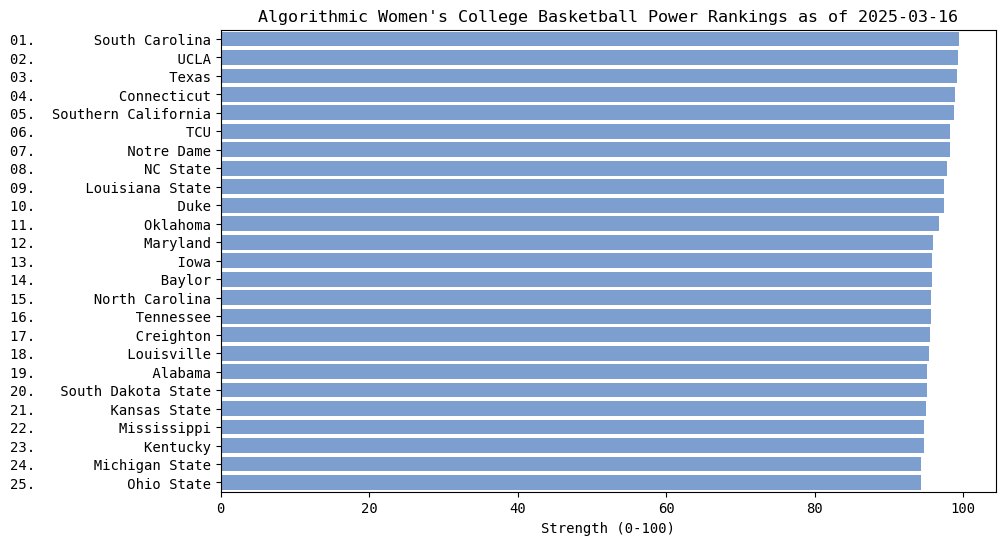

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'monospace'  # so spacing is consistent for y axis

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ratings_display.head(25)['Strength'],
    y=(
        df_ratings_display.head(25).index.map(lambda x: str(x).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ratings_display.head(25)['Team'].str.pad(max(df_ratings_display.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#6f9cde',
    dodge=False
)

plt.xlabel('Strength (0-100)')
plt.ylabel(None)
plt.title(f"Algorithmic Women's College Basketball Power Rankings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

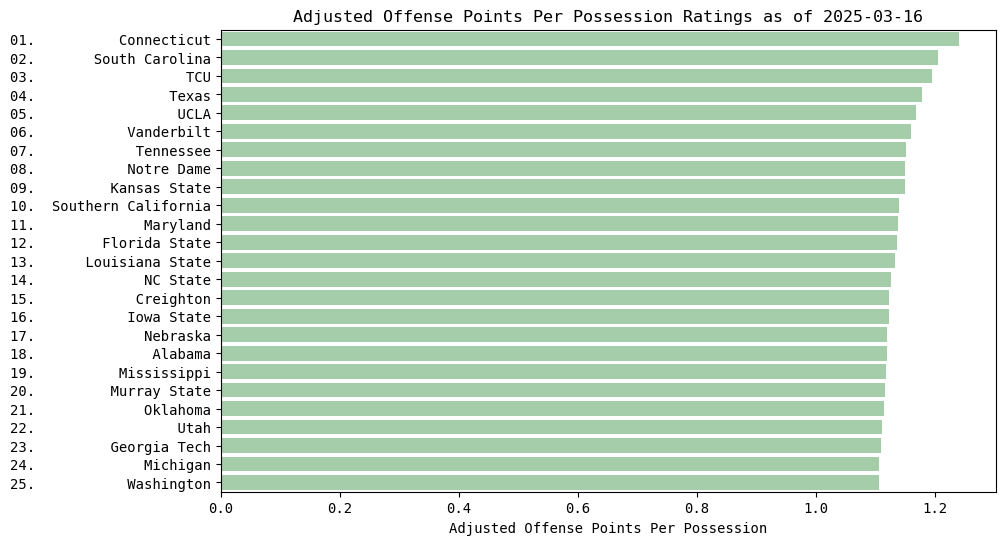

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_offense.head(25)['Rating'],
    y=(
        df_ppp_offense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_offense.head(25)['Team'].str.pad(max(df_ppp_offense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#9fd4a3',
    dodge=False
)

plt.xlabel('Adjusted Offense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Offense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

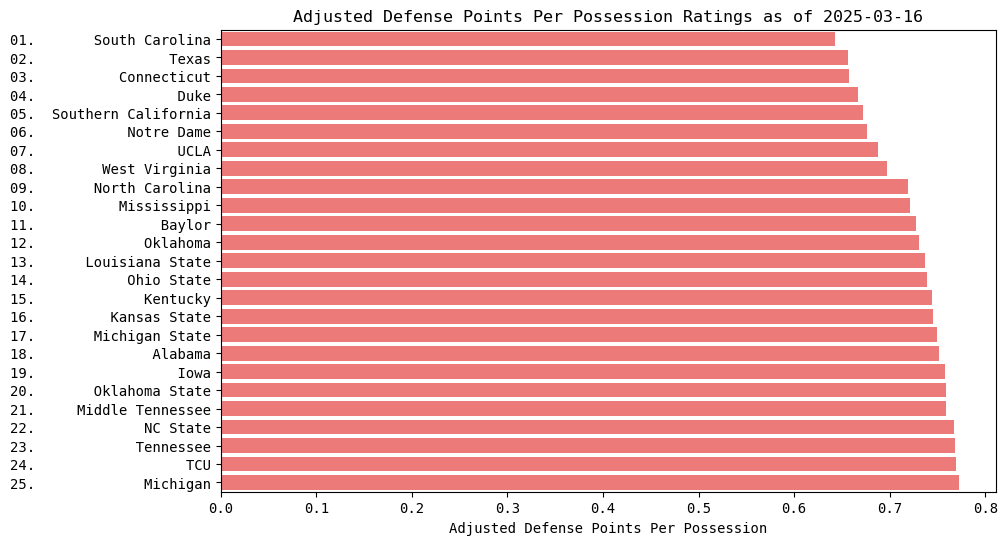

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_defense.head(25)['Rating'],
    y=(
        df_ppp_defense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_defense.head(25)['Team'].str.pad(max(df_ppp_defense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ff6865',
    dodge=False
)

plt.xlabel('Adjusted Defense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Defense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

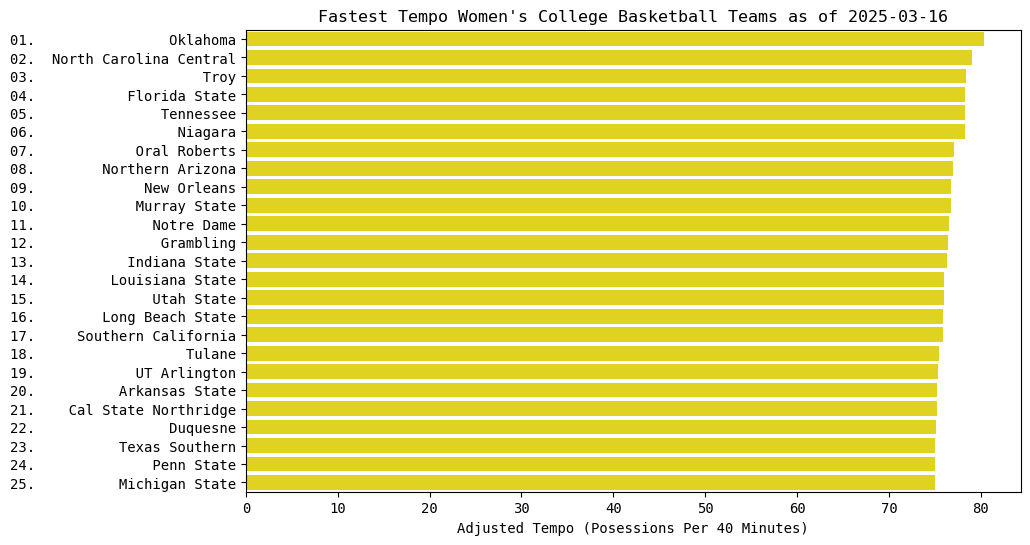

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_tempo.head(25)['Adjusted Tempo'],
    y=(
        df_tempo.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_tempo.head(25)['Team'].str.pad(max(df_tempo.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ffee00',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Fastest Tempo Women's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

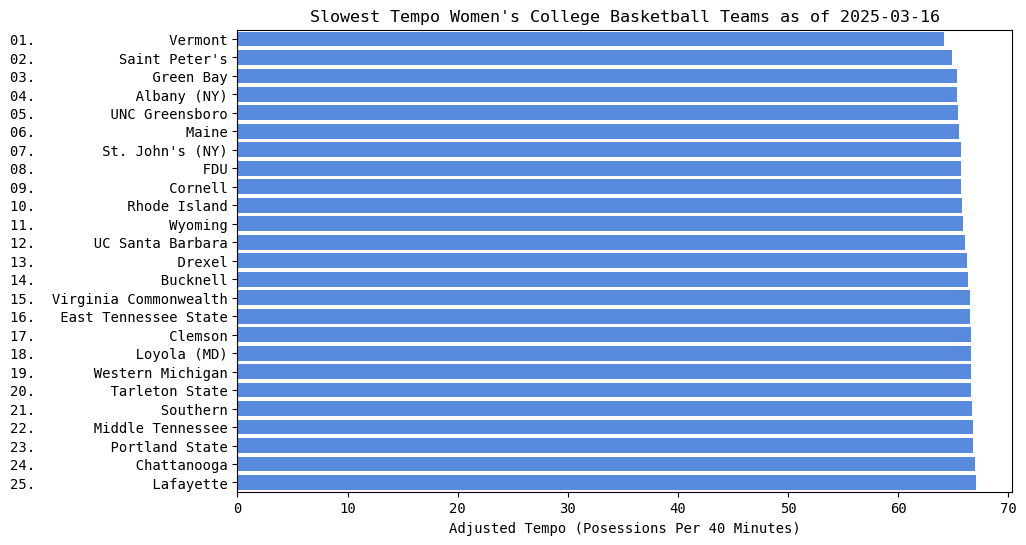

In [29]:
plt.figure(figsize=(10, 6))

df_slow = df_tempo.tail(25).iloc[::-1].reset_index(drop=True)

ax = sns.barplot(
    x=df_slow['Adjusted Tempo'],
    y=(
        df_slow.index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_slow['Team'].str.pad(max(df_slow['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#4285f4',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Slowest Tempo Women's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

In [30]:
import plotly.express as px

fig = px.scatter(
    df_ppp_all,
    x='Adjusted Offense',
    y='Adjusted Defense',
    hover_data='Team',
    title=f'Adjusted Points Per Possession Ratings as of {df["Date"].max().strftime("%Y-%m-%d")}',
    width=1_000, height=600,
)

fig.update_layout(
    font_family='monospace',
    hovermode='closest',
    yaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis_range=(df_ppp_all['Adjusted Offense'].min()-0.01, df_ppp_all['Adjusted Offense'].max()+0.01),
    yaxis_range=(df_ppp_all['Adjusted Defense'].max()+0.01, df_ppp_all['Adjusted Defense'].min()-0.01),
)

fig.update_traces(marker=dict(size=12))

fig.add_vline(
    x=df_ppp_all['Adjusted Offense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

fig.add_hline(
    y=df_ppp_all['Adjusted Defense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

# sloped gridlines
minimum = min(df_ppp_all['Adjusted Offense'].min(), df_ppp_all['Adjusted Defense'].min())-0.01
maximum = max(df_ppp_all['Adjusted Offense'].max(), df_ppp_all['Adjusted Defense'].max())+0.01

for offset in np.linspace(0, maximum-minimum, 6):
    fig.add_scatter(
        x=(minimum+offset, maximum+offset),
        y=(minimum, maximum),
        mode='lines',
        line_color='grey',
        opacity=0.25,
        showlegend=False,
        hoverinfo='skip'
    )

    if offset:
        fig.add_scatter(
            x=(minimum-offset, maximum-offset),
            y=(minimum, maximum),
            mode='lines',
            line_color='grey',
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        )

fig.show()

### Miscellaneous

##### Save Rankings

In [31]:
df_sheet = pd.merge(
    df_ratings_display, df_ppp_all,
    how='left',
    on=['Team']
)

df_sheet = pd.merge(
    df_sheet, df_tempo,
    how='left',
    on=['Team']
)

df_sheet.insert(
    df_sheet.columns.get_loc('Adjusted Offense'),
    'Efficiency Margin',
    df_sheet['Adjusted Offense'] - df_sheet['Adjusted Defense']
)

df_sheet

,Team,Rating,Strength,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo
0,South Carolina,5.147655,99.422058,0.562154,1.205098,0.642944,72.154811
1,UCLA,4.908453,99.267022,0.481295,1.168855,0.687560,71.129603
2,Texas,4.802689,99.185917,0.522286,1.179051,0.656765,70.383361
3,Connecticut,4.473622,98.872270,0.583006,1.240840,0.657834,70.633882
4,Southern California,4.409562,98.798560,0.468648,1.140761,0.672113,75.836752
...,...,...,...,...,...,...,...
357,Long Island University,-3.460222,3.046548,-0.376161,0.702026,1.078187,68.350150
358,Arkansas-Pine Bluff,-3.558144,2.770237,-0.316465,0.694982,1.011448,72.058559
359,UNC Asheville,-3.661215,2.505726,-0.325492,0.727043,1.052535,71.835725
360,South Carolina State,-3.805312,2.176788,-0.404193,0.681998,1.086191,69.509904


In [32]:
df_sheet.to_parquet(f'../data/preprocessed/womens_my_rankings/my_rankings_{season}.parquet')

'Done'

'Done'